##### NB
- You might need to run `pip install tensorflow-addons` ´to use  `f1_score`.

# Compulsory Assignment 2: Convolutional neural networks

Please fill out the the group name, number, members and optionally the name below.

**Group number**: 2 \
**Group member 1**: Kristian Mathias Røhne\
**Group member 2**: Simen Roko Krogstie\
**Group member 3**: Erling Hamil Mysen\
**Group name (optional)**: The Three Musketeers

Make sure that the group name given in the assignment is the same that you use on the Kaggle Leaderboard.

# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. The assignment is submitted by handing in this notebook as an .ipynb file and as a .pdf file. In addition, you are required to submit at least one test prediction to the Kaggle leaderboard that is better than the *BEAT ME* score.

NOTE: Remember to go through the rules given in the lecture "Introduction to compulsory assignments", as there are many do's and dont's with regard to how you should present the work you are going to submit. 

# Introduction 
This assignment will start with classifying handwritten digits from the MNIST dataset, used in the voluntary assignment and the first compulsory assignment. The second part of this task will revolve around classifying the open-source Fashion-MNIST dataset.



## Fashion-MNIST

The Fashion-MNIST is a dataset created from Zlalando's articile images(https://github.com/zalandoresearch/fashion-mnist/blob/master/README.md). The dataset consits of 70,000 labels images in 28x28 grayscale image labeld from 0 to 10. The goal of the Fashion-MNIST to work as a harder version of the handletter dataset MNIST. The Github repo for the dataset descripte the dataset to be:
- "intend Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms."


<center><img src="fashion-mnist-sprite.png" width="500" height="400"></center>


## Assignment structure

1. Part 1: Implementing LeNet5 for classifying MNIST.
2. Part 2: Designing your own CNN for classifying Fashion-MNIST

## Submissions to the Kaggle leaderboard
Use the following code to create the `submission.csv` file that you can submit to the Kaggle leaderboard. 

```python
prediction = model.predict(X_test)
flat_prediction = np.argmax(prediction, axis=1) # Flatten softmax predictions
submissionDF = pd.DataFrame()
submissionDF['ID'] = range(len(flat_prediction)) # The submission csv file must have an row index column called 'ID'
submissionDF['Prediction'] = flat_prediction
submissionDF.to_csv('submission.csv', index=False) # Remember to store the dataframe to csv without the nameless index column.
```

## Library imports

In [83]:
# Feel free to add or remove libraries as you want
from utilities import *
import time
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import ParameterGrid
import tensorflow.keras as ks
from sklearn.metrics import confusion_matrix
import tensorflow as tf



SEED = 458
RNG = np.random.default_rng(SEED) # Random number generator

# Part 1: CNN for classifying the MNIST dataset

## Loading MNIST

In [84]:
datasets = load_mnist(verbose=0)
X_train, y_train = datasets['X_train'], datasets['y_train']
X_val,   y_val   = datasets['X_val'],   datasets['y_val']
X_test,  y_test  = datasets['X_test'],  datasets['y_test']

X_train = np.concatenate([X_train, X_val], axis=0)
y_train = np.concatenate([y_train, y_val], axis=0).astype('int32')

del datasets, X_val, y_val # Good to reduce uneccesary RAM usage

## Preprocessing

In [85]:
# Reshape data to account for color channel
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Normalizing input between [0,1]
X_train = X_train.astype("float32")/np.max(X_train)
X_test  = X_test.astype("float32")/np.max(X_test)

# Converting targets from numbers to categorical format
y_train = ks.utils.to_categorical(y_train, len(np.unique(y_train)))
y_test  = ks.utils.to_categorical(y_test, len(np.unique(y_test)))

##### Implement LeNent5 architecture according to the following specifications: 

--------------------------
The LeNet architecture takes a 28x28xC image as input, where C is the number of color channels. Since MNIST images are grayscale, C is 1 in this case.

**Layer 1 - Convolution (5x5):** The output shape should be 28x28x6. **Activation:** ReLU. 

**MaxPooling:** The output shape should be 14x14x6.

**Layer 2 - Convolution (5x5):** The output shape should be 10x10x16. **Activation:** ReLU. 

**MaxPooling:** The output shape should be 5x5x16.

**Flatten:** Flatten the output shape of the final pooling layer such that it's 1D instead of 3D.  You may need to use tf.reshape.

**Layer 3 - Fully Connected:** This should have 120 outputs. **Activation:** ReLU.

**Layer 4 - Fully Connected:** This should have 84 outputs. **Activation:** ReLU.

**Layer 5 - Fully Connected:** This should have 10 outputs. **Activation:** softmax.

--------------------------


##### Compile the network with the
* `tf.keras.losses.CategoricalCrossentropy` loss function
* the `adam` optimizer 
* with the `accuracy` metric and (your own implementation of the) F1-score metric.

## Task 1.1: Build a CNN network with the LeNet5 architecture

In [86]:
#Implementation of the F1-score
# This is the same as the one we used last time
def f1_score_metric(y_true, y_pred):
    # Convert predicted probabilities to binary predictions for each class (multi-label).
    y_pred = tf.round(y_pred)

    # Calculate precision for each class.
    precision = tf.reduce_sum(tf.cast(y_true * y_pred, 'float'), axis=0) / (tf.reduce_sum(tf.cast(y_pred, 'float'), axis=0) + tf.keras.backend.epsilon())

    # Calculate recall for each class. 
    recall = tf.reduce_sum(tf.cast(y_true * y_pred, 'float'), axis=0) / (tf.reduce_sum(tf.cast(y_true, 'float'), axis=0) + tf.keras.backend.epsilon())

    # Calculate F1 score for each class.
    f1 = 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())
    
    # Return mean F1 score across all classes
    return tf.reduce_mean(f1)  

# Wrap the custom F1 score function for use as a metric
f1_metric = ks.metrics.MeanMetricWrapper(f1_score_metric, name='f1_score')

In [87]:
# Define the LeNet-5 model
def create_lenet5(input_shape=(28, 28, 1), num_classes=10):
    model = ks.models.Sequential()

    # Layer 1 - Convolution (5x5), ReLU activation
    model.add(ks.layers.Conv2D(6, kernel_size=(5, 5), padding='same', activation='relu', input_shape=input_shape))
    # MaxPooling (2x2)
    model.add(ks.layers.MaxPooling2D(pool_size=(2, 2)))

    # Layer 2 - Convolution (5x5), ReLU activation
    model.add(ks.layers.Conv2D(16, kernel_size=(5, 5), activation='relu'))
    # MaxPooling (2x2)
    model.add(ks.layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten
    model.add(ks.layers.Flatten())

    # Layer 3 - Fully Connected (120 outputs), ReLU activation
    model.add(ks.layers.Dense(120, activation='relu'))

    # Layer 4 - Fully Connected (84 outputs), ReLU activation
    model.add(ks.layers.Dense(84, activation='relu'))

    # Layer 5 - Fully Connected (10 outputs), Softmax activation
    model.add(ks.layers.Dense(num_classes, activation='softmax'))

    return model

In [88]:
#Create the model with the function above
model = create_lenet5()

# Compile the model with the custom F1-score function
model.compile(
    loss= ks.losses.CategoricalCrossentropy(),
    optimizer=ks.optimizers.Adam(),
    metrics=['accuracy', f1_metric])

# Summary of the model
model.summary()

c:\Users\Kristian Røhne\OneDrive\Høst 2024\Dat300\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_273"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_548 (Conv2D)             │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_547               │ (None, 14, 14, 6)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_549 (Conv2D)             │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_548               │ (None, 5, 5, 16)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_272 (Flatten)           │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_677 (Dense)               │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_678 (Dense)               │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_679 (Dense)               │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

### Task 1.1.2 Train network

Train the network with a 
* batch size of 64 samples
* for 20 epochs
* 1/8 validation split

In [89]:
history = model.fit(
    X_train, 
    y_train, 
    batch_size=64, 
    epochs=20, 
    validation_split=0.125
)

Epoch 1/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8426 - f1_score: 0.7759 - loss: 0.5188 - val_accuracy: 0.9723 - val_f1_score: 0.9697 - val_loss: 0.0980
Epoch 2/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9756 - f1_score: 0.9717 - loss: 0.0781 - val_accuracy: 0.9835 - val_f1_score: 0.9805 - val_loss: 0.0570
Epoch 3/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9840 - f1_score: 0.9811 - loss: 0.0521 - val_accuracy: 0.9839 - val_f1_score: 0.9805 - val_loss: 0.0583
Epoch 4/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9884 - f1_score: 0.9847 - loss: 0.0384 - val_accuracy: 0.9837 - val_f1_score: 0.9801 - val_loss: 0.0564
Epoch 5/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9888 - f1_score: 0.9872 - loss: 0.0358 - val_accuracy: 0.9867 - val_f1_score: 0.9839 - val_loss: 0.0451
Epoch 6/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9909 - f1_score: 0.9887 - loss: 0.0276 - val_accuracy: 0.9860 - val_f1_score: 0.983

## Task 1.2 Evaluaiton
### Task 1.2.1 Plot training history and evaluate on test dataset

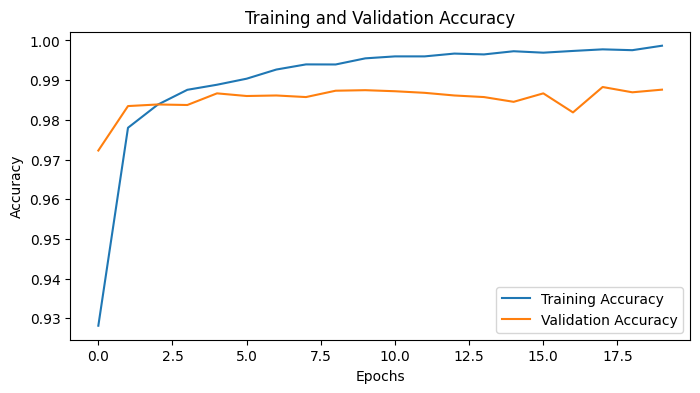

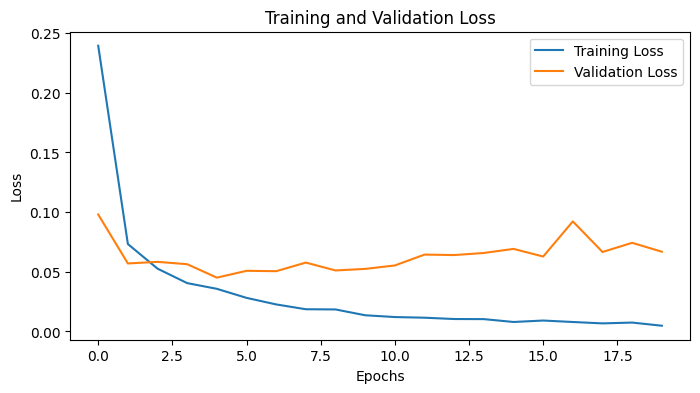

In [90]:
# Plot the training history
def plot_training_history(history):
    # Extract values from history
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Create accuracy plot
    plt.figure(figsize=(8, 4))
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.show()

    # Create loss plot
    plt.figure(figsize=(8, 4))
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

# Call the function with the history from model.fit
plot_training_history(history)


### Task 1.2.2 Evaluate on the test dataset

In [91]:
# Evaluate the model on the test dataset
test_loss, test_accuracy, test_f1_score = model.evaluate(X_test, y_test, verbose=2)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test F1 Score: {test_f1_score}")


313/313 - 0s - 1ms/step - accuracy: 0.9902 - f1_score: 0.9637 - loss: 0.0478
Test Loss: 0.04781828448176384
Test Accuracy: 0.9901999831199646
Test F1 Score: 0.9636747241020203


### Task 2.2.3 Create a confution matrix for both traing and testing data
- Does the test data and train data predikt the same items wrong?

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


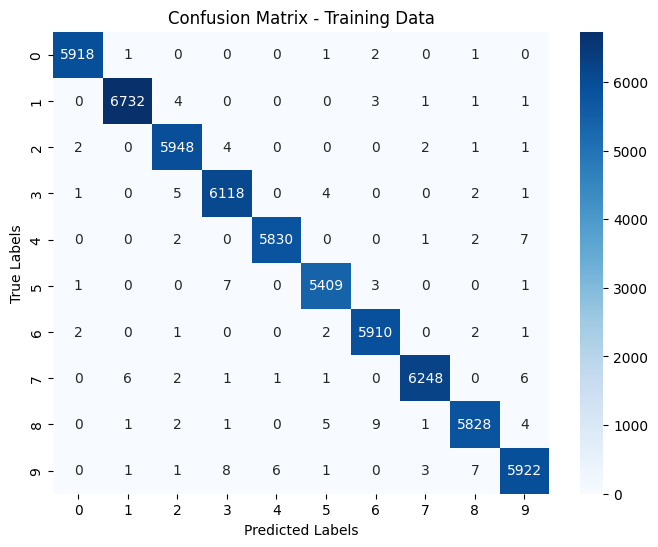

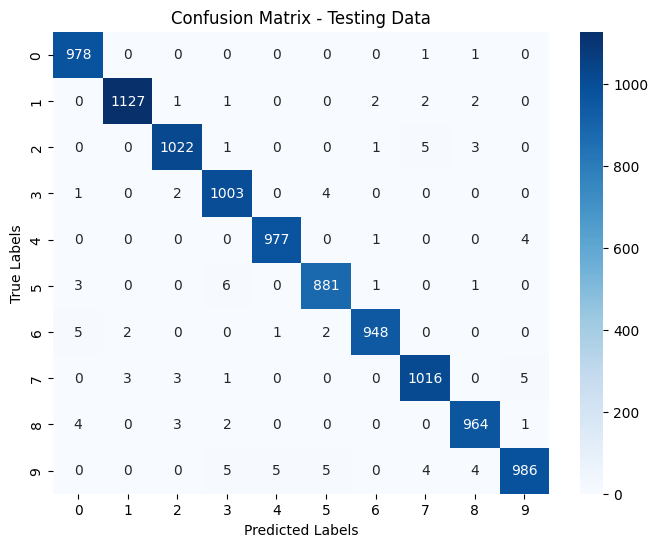

In [92]:
# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(title)
    plt.show()

# Get predictions for training and testing data
y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_train_true = np.argmax(y_train, axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)
y_test_true = np.argmax(y_test, axis=1)

# Plot confusion matrix for training data
plot_confusion_matrix(y_train_true, y_train_pred, title='Confusion Matrix - Training Data')

# Plot confusion matrix for testing data
plot_confusion_matrix(y_test_true, y_test_pred, title='Confusion Matrix - Testing Data')

Answer to task 2.2.3: Yes, it looks like they mostly predict the same things wrongs. We see that that in both test and training data:
- Some 8 are predicted as 2 and 3.
- Some 5 are predicted as 3. 
- Some 9 are predicted as 4 and 4. 

This is some examples where both training and test data predict the same wrong.

## Task 2.3: MNIST discussion

**Task 2.3.1: What is overfititng and how does it ocure during training of the LeNet-5 model**

**Task 2.3.2: What is ReLU and Leaky ReLU, what is their derivative and how does their derative solve the vanesting gradient problem?**

**Task 2.3.3: Calculate the Number of Trainable Parameters and the Output Shape of Feature Maps for LeNet-5 at Each Layer**

Answer to 2.3.1: Overfitting is when the model get's too good on evalutaing the training data. Then the model won't be as good as predicitng unseen and new data because it is too complex for the data that it already has seen. A sign of overfitting is when the training accuracy get's higher than the validation and test accuracy. Wee that in the training plots that the training accuracy get's higher than the validation accuracy after 2 epochs, so the model is overfitting very early.

Answer to 2.3.2: Relu is an activation function defined as the non-negative part of its argument:

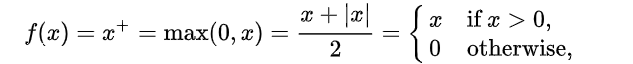

ReLU is effective for positive inputs, but it has zero gradient for negative values, which can cause some neurons to "die." It's derivative is :

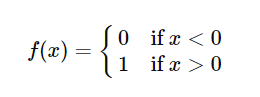

Leaky ReLUs is also an activaiton function and allows a small, positive gradient when the unit is not active, helping to mitigate the vanishing gradient problem.

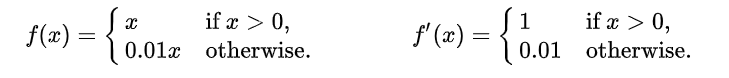

Both ReLU and Leaky ReLU is used in neural networks to introduce non-linearity, enabling the network to learn complex patterns. They are particularly popular in deep learning because of their simplicity and effectiveness.

Answer to 2.3.3: Input layers: no trainable parameters
Layer 1: using this formula: 
 
 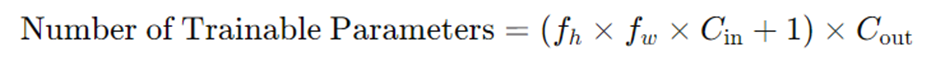
 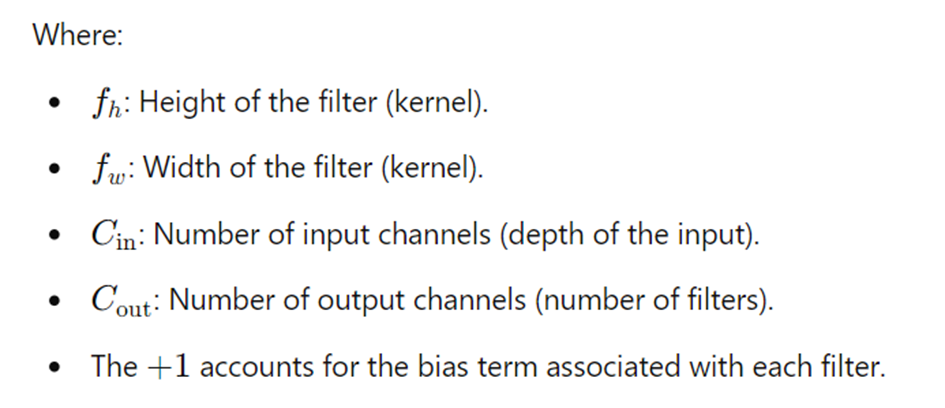
 

No trainable paramters when flattening output and maxpooling.

For first layer: 
Since kernel size is 5x5, input channel is 1 and output channel is 6, the equation for trainable parameters is: 
(5*5*1+1) * 6 = 156 paramters.

Layer 2: kernel size 5x5, input channel is 6, output channel is 16, so trainable paramters is: (5*5*6+1)*16= 2416 paramters 

Layer 2 maxpooling. No trainable paramters:

Layer 3: now input size is 400, because of flatteing in layer 2. Since output size is 120, trainable paramters is 400*120+ 120= 48120 trainble paramters  (formula is weights + biases= trainable parameters) 

Layer 4: Since input size is 120 and output is 84, trainable parameters is 120*84 + 84= 10164 trainable paramters

Layer 5: input size 84, output size is 10, so trainable paramters is 84*10 + 10= 850 trainable paramters

Trainable paramters for whole model is 156 + 2416 + 48120 + 10164+ 850 = 61706 trainable paramters.


# Task 2: CNN for classifying the Fashion-MNIST dataset

In this task you shall implement a CNN model, and train it to classify the images in the Fashion-MNIST dataset.

## Importing Fashion-MNIST

- Filename: `Fashion_MNIST.h5`

In [93]:
FILE_PATH = "Fashion_MNIST.h5" # If data is in same directory as Jypyter File

labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot" 
}

In [94]:
with h5py.File(FILE_PATH,'r') as f:
    print('Datasets in file:', list(f.keys()))
    X_train = np.asarray(f['train_images'])
    y_train = np.asarray(f['train_labels'])
    X_test  = np.asarray(f['test_images'])
    print('Nr. train images: %i'%(X_train.shape[0]))
    print('Nr. test images: %i'%(X_test.shape[0]))

Datasets in file: ['test_images', 'train_images', 'train_labels']
Nr. train images: 59500
Nr. test images: 10500


## Task 2.1: Preprocess the data
Preprocess the data as you see fit

In [95]:
# Normalize and reshape input data
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(-1, 28, 28, 1).astype(np.float32)
X_test = X_test.reshape(-1, 28, 28, 1).astype(np.float32)

# Ensure labels are integers for sparse_categorical_crossentropy
y_train = y_train.astype(np.int32)



## Task 2.2: Visualize the dataset
Plot a few samples images and the distrbution of classes in the data. 

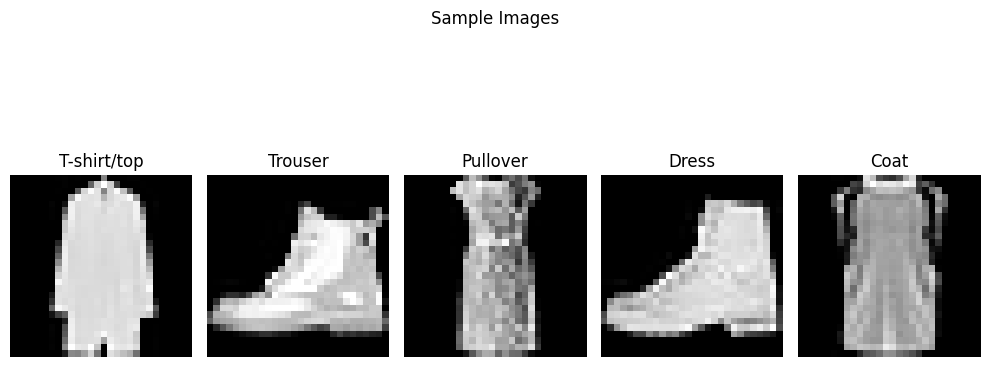

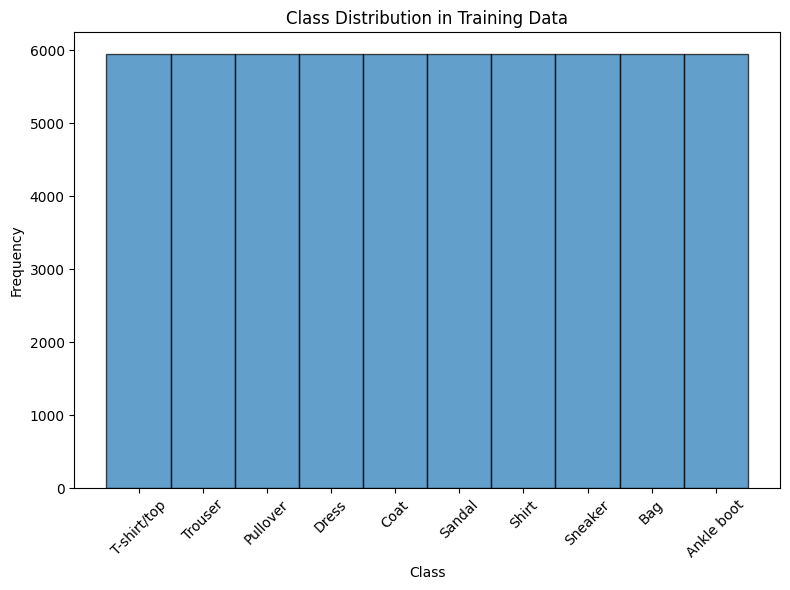

In [96]:
# Sample data for illustration
X_train_sample = X_train[:5] 
y_train_sample = [0, 1, 2, 3, 4]  

# Plot a few sample images with labels
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train_sample[i].reshape(28, 28), cmap='gray')
    plt.title(labels[y_train_sample[i]])
    plt.axis('off')
plt.suptitle("Sample Images")
plt.tight_layout()
plt.show()

# Plot the distribution of classes in the training data

plt.figure(figsize=(8, 6))
plt.hist(y_train, bins=np.arange(11) - 0.5, edgecolor='black', alpha=0.7)
plt.xticks(ticks=range(10), labels=[labels[i] for i in range(10)], rotation=45)
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Class Distribution in Training Data')
plt.tight_layout()
plt.show()


## Task 2.3: Build a CNN for Classifying the Fashion-MNIST Dataset
Build a CNN model and beat the "Beat Me" score on Kaggle.

- Experiment with different kernel sizes, strides, and types/number of layers.
- Don’t overcomplicate it; focues on as grounds for discussion when you make the models.
Tips: When you make changes to the model, save some earlier iterations.
You need only one model scored higher than "Beat Me."

In [97]:

#Function for creating a model. 
def create_model(kernel_size, strides, num_conv_layers, num_dense_layers, conv_filters, dense_units, dropout_rate):
    model = ks.models.Sequential()
    model.add(ks.Input(shape=(28, 28, 1)))

    # Add convolutional layers
    for i in range(num_conv_layers):
        model.add(ks.layers.Conv2D(
            filters=conv_filters[i],
            kernel_size=kernel_size,
            strides=strides,
            activation='relu',
            padding='same'
        ))
        model.add(ks.layers.MaxPooling2D(pool_size=(2, 2), padding='same'))

    model.add(ks.layers.Flatten())

    # Add dense layers
    for _ in range(num_dense_layers):
        model.add(ks.layers.Dense(
            dense_units,
            activation='relu',
        ))
        if dropout_rate > 0:
            model.add(ks.layers.Dropout(dropout_rate))

    # Output layer
    model.add(ks.layers.Dense(10, activation='softmax'))

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [102]:
# Defining hyperparameters to experiment with
param_grid = {
    'kernel_size': [(3, 3), (5, 5)],
    'strides': [(1, 1), (2, 2)],
    'num_conv_layers': [2, 3],
    'num_dense_layers': [1, 2],
    'conv_filters': [[32, 64], [64, 128], [32, 64, 128]],
    'dense_units': [128, 256],
    'dropout_rate': [0, 0.1, 0.2],
    'batch_size': [64]
}

# Filter out incompatible configurations
filtered_grid = []
for params in ParameterGrid(param_grid):
    if len(params['conv_filters']) == params['num_conv_layers']:
        filtered_grid.append(params)

# Iterate through the filtered parameter grid
best_accuracy = 0
best_params = None
best_model = None

for params in filtered_grid:
    try:
        print(f"Training model with params: {params}")
        
        model = create_model(
            kernel_size=params['kernel_size'],
            strides=params['strides'],
            num_conv_layers=params['num_conv_layers'],
            num_dense_layers=params['num_dense_layers'],
            conv_filters=params['conv_filters'],
            dense_units=params['dense_units'],
            dropout_rate=params['dropout_rate']
        )

        # Early stopping and learning rate reduction callbacks
        early_stopping = ks.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
        lr_scheduler = ks.callbacks.ReduceLROnPlateau(
            monitor='val_loss',  
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )

        # Train the model with validation split
        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=10,
            batch_size=params['batch_size'],
            callbacks=[early_stopping, lr_scheduler],
            verbose=0
        )
        
        # Get the validation accuracy
        val_accuracy = max(history.history['val_accuracy'])
        print(f"Validation accuracy: {val_accuracy:.4f}")

        # Use the plot_training_history function for plotting (assuming defined elsewhere)
        plot_training_history(history)

        # Check if this model is the best so far
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_params = params
            best_model = model
    
    except Exception as e:
        print(f"Failed to train model with params {params}: {e}")

print(f"\nBest validation accuracy: {best_accuracy:.4f}")
print(f"Best parameters: {best_params}")

# Save the best model for later use
if best_model:
    best_model.save('best_fashion_mnist_model.h5')

Training model with params: {'batch_size': 64, 'conv_filters': [32, 64], 'dense_units': 128, 'dropout_rate': 0, 'kernel_size': (3, 3), 'num_conv_layers': 2, 'num_dense_layers': 1, 'strides': (1, 1)}


KeyboardInterrupt: 

The code over is for finding a model with a good conifuguration. It took a lot of time running the code (with no surprise), so we didn't have the patience to try everything. We looked over different models with different configurations, and kept going with the configuration that gave us the best score, which is below. I also stopped the code so you didnt have to look at all the output.

In [99]:
# Define model parameters
params = {
    'batch_size': 64,
    'conv_filters': [32, 64],
    'dense_units': 256,
    'dropout_rate': 0.2,
    'kernel_size': (3, 3),
    'num_conv_layers': 2,
    'num_dense_layers': 1,
    'strides': (1, 1)
}

# Create the model using the existing function
model = create_model(
    kernel_size=params['kernel_size'],
    strides=params['strides'],
    num_conv_layers=params['num_conv_layers'],
    num_dense_layers=params['num_dense_layers'],
    conv_filters=params['conv_filters'],
    dense_units=params['dense_units'],
    dropout_rate=params['dropout_rate'],
)

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
# Learning rate reduction on plateau
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the model using the data generator
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# Get the validation accuracy
val_accuracy = max(history.history['val_accuracy'])
print(f"Validation accuracy: {val_accuracy:.4f}")


Epoch 1/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7855 - loss: 0.5970 - val_accuracy: 0.8838 - val_loss: 0.3167 - learning_rate: 0.0010
Epoch 2/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8939 - loss: 0.2886 - val_accuracy: 0.9056 - val_loss: 0.2578 - learning_rate: 0.0010
Epoch 3/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.9133 - loss: 0.2344 - val_accuracy: 0.9180 - val_loss: 0.2225 - learning_rate: 0.0010
Epoch 4/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9279 - loss: 0.1949 - val_accuracy: 0.9191 - val_loss: 0.2226 - learning_rate: 0.0010
Epoch 5/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9375 - loss: 0.1673 - val_accuracy: 0.9191 - val_loss: 0.2284 - learning_rate: 0.0010
Epoch 6/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9461 - loss: 0.1417 - val_accuracy: 0.9203 - val_loss: 0.2275 - learning_rate: 0.0010
Epoch 7/20
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accura

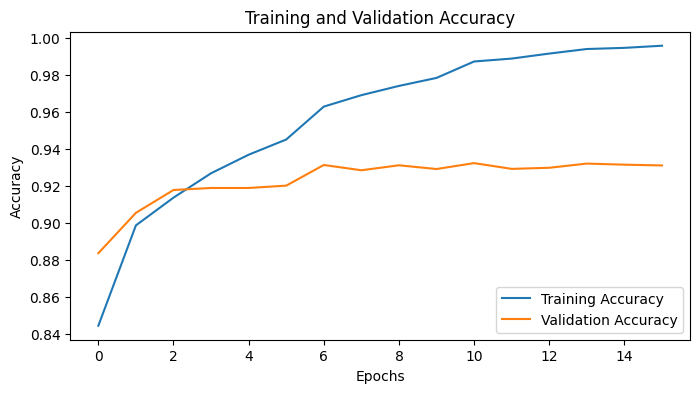

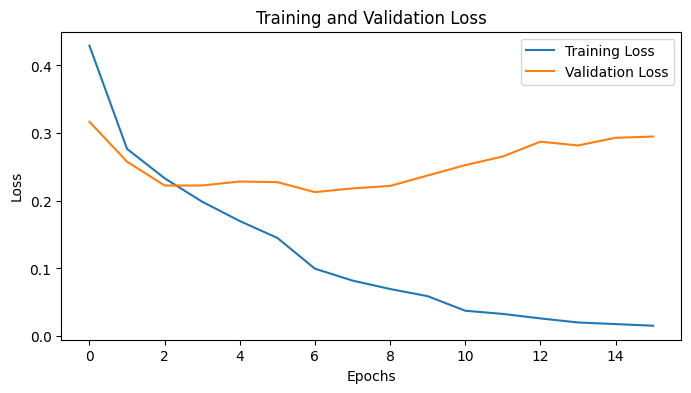

In [100]:
plot_training_history(history)

## Task 2.4: Evaluate your best model on the test dataset and submit your prediction to the Kaggle leaderboard

In [101]:
Kaggle_model_prediction = model.predict(X_test)
flat_Kaggle_model_prediction_prediction = np.argmax(Kaggle_model_prediction, axis=1)
submissionKaggle = pd.DataFrame()
submissionKaggle['ID'] = range(len(flat_Kaggle_model_prediction_prediction))
submissionKaggle['Prediction'] = flat_Kaggle_model_prediction_prediction
submissionKaggle.to_csv('KaggelSubmission.csv', index=False)

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


# Task 2.5: Fashion-MNIST Discussion

### Task 3.5.1
- Feel Free to experimant on acitecture
- Comment on the choice of layers and hyper paramters. 
    - Did you find some different results in changing a hyer paramter or add/remove a layer.


Answer to task 3.5.1: All of the different models we tried performed well, but some achieved higher accuracy than others. It became clear that having at least two convolutional layers was necessary to achieve better accuracy. Additionally, only a single dense layer was needed for the model, indicating that the CNN didn’t have to be overly complex to recognize patterns effectively. A kernel size of 3x3 was sufficient for the convolutional layers. The dropout technique helped mitigate overfitting to some extent, but the final model still suffered from significant overfitting. To improve the model further, we could have incorporated more regularization techniques and possibly used a data generator to simplify the model while retaining its performance.